<a href="https://colab.research.google.com/github/nickolas-eisenbarth/Freshman-notebook/blob/main/lectures/Lecture34.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recap:

*   Linear Algebra in Numpy








In [ ]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# Application 1:

Given two points $(x_1,y_1)$ and $(x_2,y_2)$, can you have a line $y = f(x)$ passing throught these two points?

* Equation of a line:
$$ y = a_1+a_2 x$$

* We want this to hold for both points, so we have a system:
$$\begin{aligned}
&y_1 = a_1+a_2x_1\\
&y_2 = a_1+a_2x_2
\end{aligned}$$

  - $a_1$ and $a_2$ are the unknowns
  - $x_1,y_1,x_2,y_2$ are known.
  - Task: solving for $a_1$ and $a_2$.

* Strategy for rearranging in matrix form:
  - Collect all unknowns on the left hand side;
  - Collect all knowns on the right side;
  - Coeffients in front of the unknowns go in the matrix $\mathbf A$;
  - Unknowns go into a vector $\mathbf u$
  - Knowns go into another vector $\mathbf b$.
  $$\begin{aligned}
&y_1 = a_1+a_2x_1\\
&y_2 = a_1+a_2x_2
\end{aligned}\Rightarrow \underbrace{\begin{bmatrix}
1&x_1\\
1&x_2
\end{bmatrix}}_{\mathbf A}\underbrace{\begin{bmatrix}
a_1\\
a_2
\end{bmatrix}}_{\mathbf u} = \underbrace{\begin{bmatrix}
y_1\\
y_2
\end{bmatrix}}_{\mathbf b}$$

* Recall Lecture 33: `numpy.linalg.solve`:
`u = la.solve(A, b)`

Example:

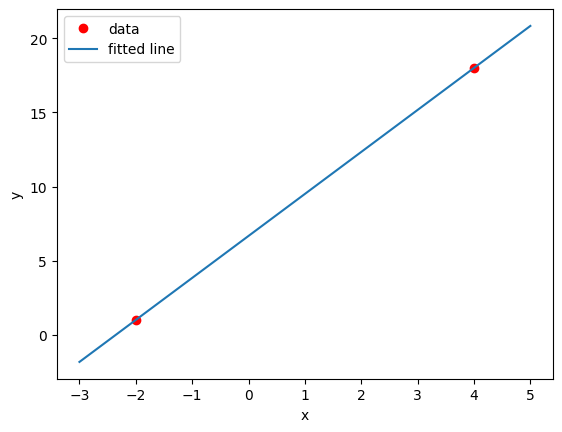

In [ ]:
# given two points:
x1 = -2
y1 = 1
x2 = 4
y2 = 18
# form matrix
A = np.array([[1, x1], [1, x2]])
# form vector
b = np.array([y1, y2])
# solve for u
u = la.solve(A, b)
a1 = u[0]
a2 = u[1]
x_fine = np.linspace(-3, 5, 100)
y_fine = a1 + a2 * x_fine
# plot the data and the fitted line
plt.plot([x1,x2], [y1,y2], "ro", label="data")
plt.plot(x_fine, y_fine, label="fitted line")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Application 2:
### Exercise: Implement the [Conway's game of life](https://en.wikipedia.org/wiki/Conway%27s_Game_of_Life) using numpy

* practice numpy matrix
* 2D plotting

In [ ]:
np.random.rand(3,3)

array([[0.95166369, 0.73057747, 0.2310508 ],
       [0.31614429, 0.15145933, 0.53772622],
       [0.04726425, 0.17291349, 0.27439824]])

In [ ]:
def create_board(rows, cols):
    """
    Creates a random initial board of the specified size.
    1: live cell
    0: dead cell
    """
    return (np.random.rand(rows,cols)>0.5).astype(int)

In [ ]:
(np.random.rand(3,3)>0.5).astype(int)

array([[0, 1, 1],
       [1, 1, 1],
       [0, 1, 1]])

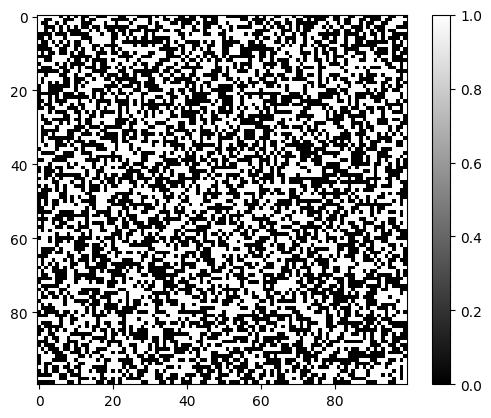

In [ ]:
board = create_board(100, 100)
plt.imshow(board, cmap='gray')
plt.colorbar()
plt.show()

## Implement 1--`count_neighbors(board)`

In [ ]:
def count_neighbors(board):
    """
    Counts the number of live neighbors for each cell in the board
    """
    rows, cols = board.shape
    neighbors = np.zeros_like(board)

    neighbors[1:,1:]+= board[:-1,:-1]# left-top element
    neighbors[1:,:-1]+= board[:-1,1:] # right-top
    neighbors[1:,:] +=board[:-1,:] #top
    neighbors[:-1,1:] +=board[1:,:-1] # bot-left
    neighbors[:-1,:-1]+=board[1:,1:] # bot-right
    neighbors[:-1,:]+=board[1:,:] # bot
    neighbors[:,1:]+=board[:,:-1] # right
    neighbors[:,:-1]+=board[:,1:] # left


    return neighbors

## The rules are:

1.   Survival: A live cell with 2 or 3 live neighbors stays alive.
2.   Birth: A dead cell with exactly 3 live neighbors becomes alive.
3.   Death: All other cells (live or dead) die or stay dead.



## Implement 2-`step(board)`

In [ ]:
def step(board):
    """
    Advances the board by one step in Conway's Game of Life.
    """
    neighbors = count_neighbors(board)
    # Apply the rules of the Game of Life
    # 1. A live cell with 2 or 3 live neighbors stays alive: board & ((neighbors == 2) | (neighbors == 3))
    # 2. A dead cell with exactly 3 live neighbors becomes alive. (~board & (neighbors == 3)
    new_board = (board & ((neighbors == 2) | (neighbors == 3))) | (~board & (neighbors == 3))
    return new_board

## Test a 3 by 3 board

In [ ]:
board = create_board(3, 3)
board

array([[1, 1, 0],
       [1, 0, 0],
       [1, 0, 1]])

In [ ]:
neighbors = count_neighbors(board)
neighbors

array([[2, 2, 1],
       [3, 5, 2],
       [1, 3, 0]])

In [ ]:
new_board = step(board)
new_board

array([[1, 1, 0],
       [1, 0, 0],
       [0, 1, 0]])

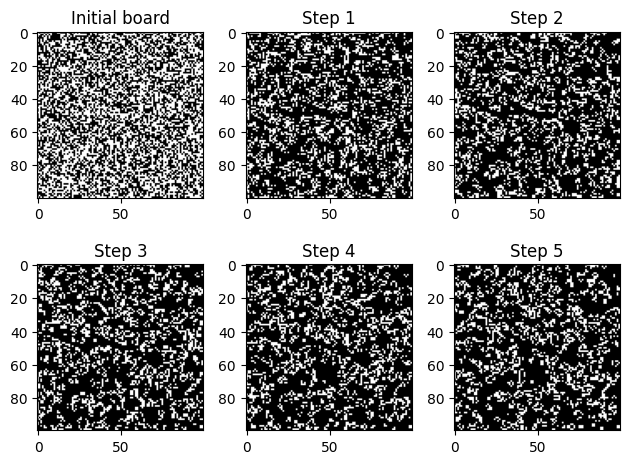

In [ ]:
board = create_board(100, 100)
fig, ax = plt.subplots(nrows=2, ncols=3)
ax[0, 0].imshow(board, cmap='gray')
ax[0, 0].set_title("Initial board")
for i in range(1, 6):
    board = step(board)
    ax[i//3, i%3].imshow(board, cmap='gray')
    ax[i//3, i%3].set_title(f"Step {i}")

plt.tight_layout()

# Save the plot
plt.savefig("game_of_life_5steps.png", dpi=300)  # Save as PNG with high resolution

plt.show()

### Make a movie

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
# Initialize the board
board = create_board(100, 100)

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(board, cmap='gray')
title = ax.set_title("Step 0", fontsize=16)
ax.axis('off')  # Turn off axes for a cleaner look

def update(frame):
    """
    Update the board for the animation.
    """
    global board
    board = step(board)
    im.set_data(board)  # Update the image with the new board
    title.set_text(f"Step {frame + 1}")  # Update the title with the current step number
    return [im]

# Create the animation
frames = 100  # Number of frames in the animation
ani = FuncAnimation(fig, update, frames=frames, blit=True)

# Save as a movie file (MP4)
ani.save("game_of_life.mp4", fps=10, dpi=300, writer='ffmpeg')  # Requires ffmpeg installed

plt.show()